In [1]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.datasets import make_blobs
from sklearn.inspection import DecisionBoundaryDisplay
import matplotlib.pyplot as plt

/home/UR/coelhrod/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## 1 Classification de spam avec un SVM linéaire
Nous considérons un problème de classification de spam avec un ensemble de données contenant
4601 courriels et 57 caractéristiques :

- 48 caractéristiques ∈ [0, 100] représentant le pourcentage de mots dans l’e-mail qui corres-
pondent à un mot donné d’une liste fixe (”business”, ”free”, etc.)
- 6 caractéristiques ∈ [0, 100] représentant le pourcentage de caractères dans l’e-mail qui cor-
respondent à un caractère donné parmi ”(”, ”[”, ” !”, ”$”, ”#”
- les caractéristiques 55-57 sont la longueur moyenne des séquences ininterrompues de lettres
majuscules, la longueur maximale de ces séquences, et le nombre total de lettres majuscules
dans l’e-mail

Le jeu de données spambase.data et les noms des caractéristiques spambase_variable.csv sont
disponibles sur la plateforme UniversiTICE.

1. Commencez par charger le jeu de données :

In [2]:
dataspam = np.loadtxt("spambase.data", delimiter=",")
features_name = np.genfromtxt("spambase_variables.csv", delimiter=",", dtype="str")
features_name = features_name [:,0]
X = dataspam [: ,0:57]
y = dataspam [:,-1]

Combien d’instances y a-t-il dans chaque classe ?

In [3]:
print("Non Spams =", np.count_nonzero(y == 0))
print("Spams =", np.count_nonzero(y == 1))

Non Spams = 2788
Spams = 1813


2. Séparez les données en un sous-ensemble d’apprentissage, un sous-ensemble de validation et un sous-ensemble de test. Utilisez un tiers des données pour chaque sous-ensemble.

In [4]:
x_temp, x_test, y_temp, y_test = train_test_split(X, y, test_size=0.33, random_state=42, stratify=y)
x_train, x_valid, y_train, y_valid = train_test_split(x_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Train: {len(y_train)/len(y)*100:.2f}%")
print(f"Valid: {len(y_valid)/len(y)*100:.2f}%")
print(f"Test: {len(y_test)/len(y)*100:.2f}%")

Train: 33.49%
Valid: 33.01%
Test: 33.49%


3. Normalisez les données en utilisant la méthode StandardScaler, comme vu dans le TP3.

In [5]:
sc = StandardScaler(with_mean=True , with_std=True)
sc = sc.fit(x_train)
Xa_n = sc.transform(x_train)
Xv_n = sc.transform(x_valid)
Xt_n = sc.transform(x_test)

4. En utilisant les ensembles d’apprentissage et de validation, déterminez la valeur optimale du paramètres C pour un SVM linéaire. Vous pouvez tester des valeurs dans l’intervalle [$10^{−3}, 10^2$]

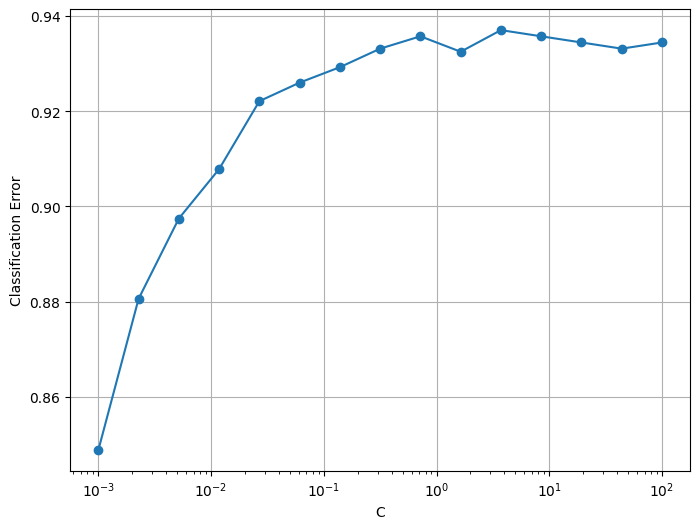

Best C value: 3.7275937203149416
Max Accuaracy Valid: 93.71%


In [7]:
C_values = np.logspace(-3, 2, 15)
Accuaracy = [] 

for C in C_values:
    clf = SVC(kernel='linear', C=C)
    clf.fit(Xa_n, y_train)

    y_pred = clf.predict(Xv_n)
    acc = accuracy_score(y_valid, y_pred)  # Classification Error
    Accuaracy.append(acc)
plt.show()

plt.figure(figsize=(8, 6))
plt.semilogx(C_values, Accuaracy, marker='o')
plt.xlabel('C')
plt.ylabel('Classification Error')
plt.grid(True)
plt.show()

best_C = C_values[np.argmax(Accuaracy)]
print("Best C value:", best_C)
print(f"Max Accuaracy Valid: {np.max(Accuaracy)*100:.2f}%")

5. Entrainez un SVM linéaire avec la valeur optimale de C et testez-le sur l’ensemble de test. Quelle est la performance obtenue ?

In [8]:
clf = SVC(kernel='linear', C=best_C)
clf.fit(Xa_n, y_train)

y_pred = clf.predict(Xt_n)
acc_SVC = accuracy_score(y_test, y_pred)

print(f"Accuracy SVC = {acc_SVC *100:.2f}%")

Accuracy SVC = 91.90%


<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    It is important to note a small percentage difference between validation and test accuracy; a 60/20/20 distribution could be more interesting.
  </p>
</div>

6. Comparez cette performance avec celle d’un modèle de regrésion logistique. Quel modèle est
le plus performant ?

In [9]:
model = LogisticRegression()
model.fit(Xa_n, y_train)

y_pred = model.predict(Xt_n)
acc_LR = accuracy_score(y_test, y_pred)


print(f"Accuracy LR = {acc_LR *100:.2f}%")
print(f"Accuracy SVC = {acc_SVC *100:.2f}%")


Accuracy LR = 91.71%
Accuracy SVC = 91.90%


<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    Both models are performing well on this dataset, but the SVC has shown to be slightly more accurate.
  </p>
</div>

## 2 Classification multi-classe avec un SVM linéaire
Nous allons maintenant considérer un problème de classification multi-classe. Pour cela, nous allons utiliser la fonction make_blobs de Scikit-learn.
1. Générer le jeu de données :

In [10]:
centers = [[2.5 , 2.5], [-1, -1], [1, -1]] # roxo, cyan, amarelo
stds = [0.5, 1.3, 0.6]
X, y = make_blobs(n_samples =150, centers=centers , cluster_std=stds)

2. Visualisez le nuage de points obtenu

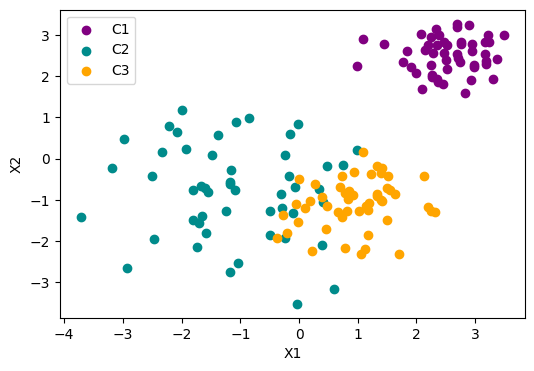

In [11]:
def plot_data():
    plt.figure(figsize=(6, 4))
    plt.scatter(X[y==0][:,0], X[y==0][:,1], color='purple', label='C1')
    plt.scatter(X[y==1][:,0], X[y==1][:,1], color='darkcyan', label='C2')
    plt.scatter(X[y==2][:,0], X[y==2][:,1], color='orange', label='C3')
    plt.legend()
    plt.xlabel("X1")
    plt.ylabel("X2")
    plt.show()

plot_data()

3. Entraînez un SVM linéaire sur ces données avec la classe SVC en utilisant la paramétrisation par défaut

In [12]:
x_temp, x_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
x_train, x_valid, y_train, y_valid = train_test_split(x_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

clf = SVC(kernel='linear') # default=1.0
clf.fit(x_train, y_train)

SVC(kernel='linear')

4. Visualisez les frontières de décision obtenues. Vous pouvez utiliser DecisionBoundaryDisplay pour cela :

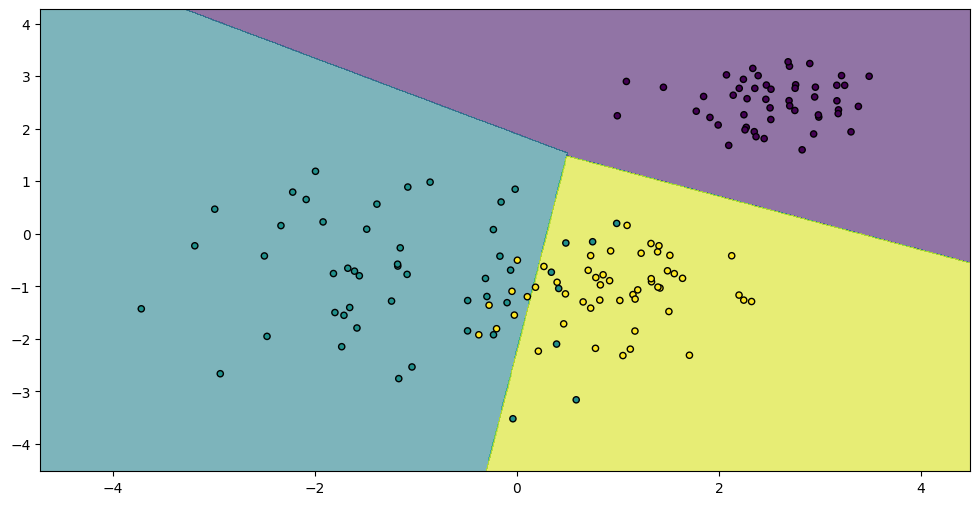

In [13]:
fig , ax = plt.subplots (1, 1, figsize =(12, 6))
disp = DecisionBoundaryDisplay.from_estimator(
    clf , X, ax=ax , grid_resolution =1000 , alpha =0.6
    )
ax.scatter(X[:, 0], X[:, 1], c=y, s=20, edgecolors='k')
plt.show()

5. En consultant la documentation de Scikit-learn, expliquez quelle est la stratégie utilisée pour gérer la classification multi-classe.

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    As mentioned in the documentation, "the multiclass support is handled according to a one-vs-one scheme."
  </p>
</div>

6. Testez différentes valeurs de C pour voir l’impact sur les frontières de décision

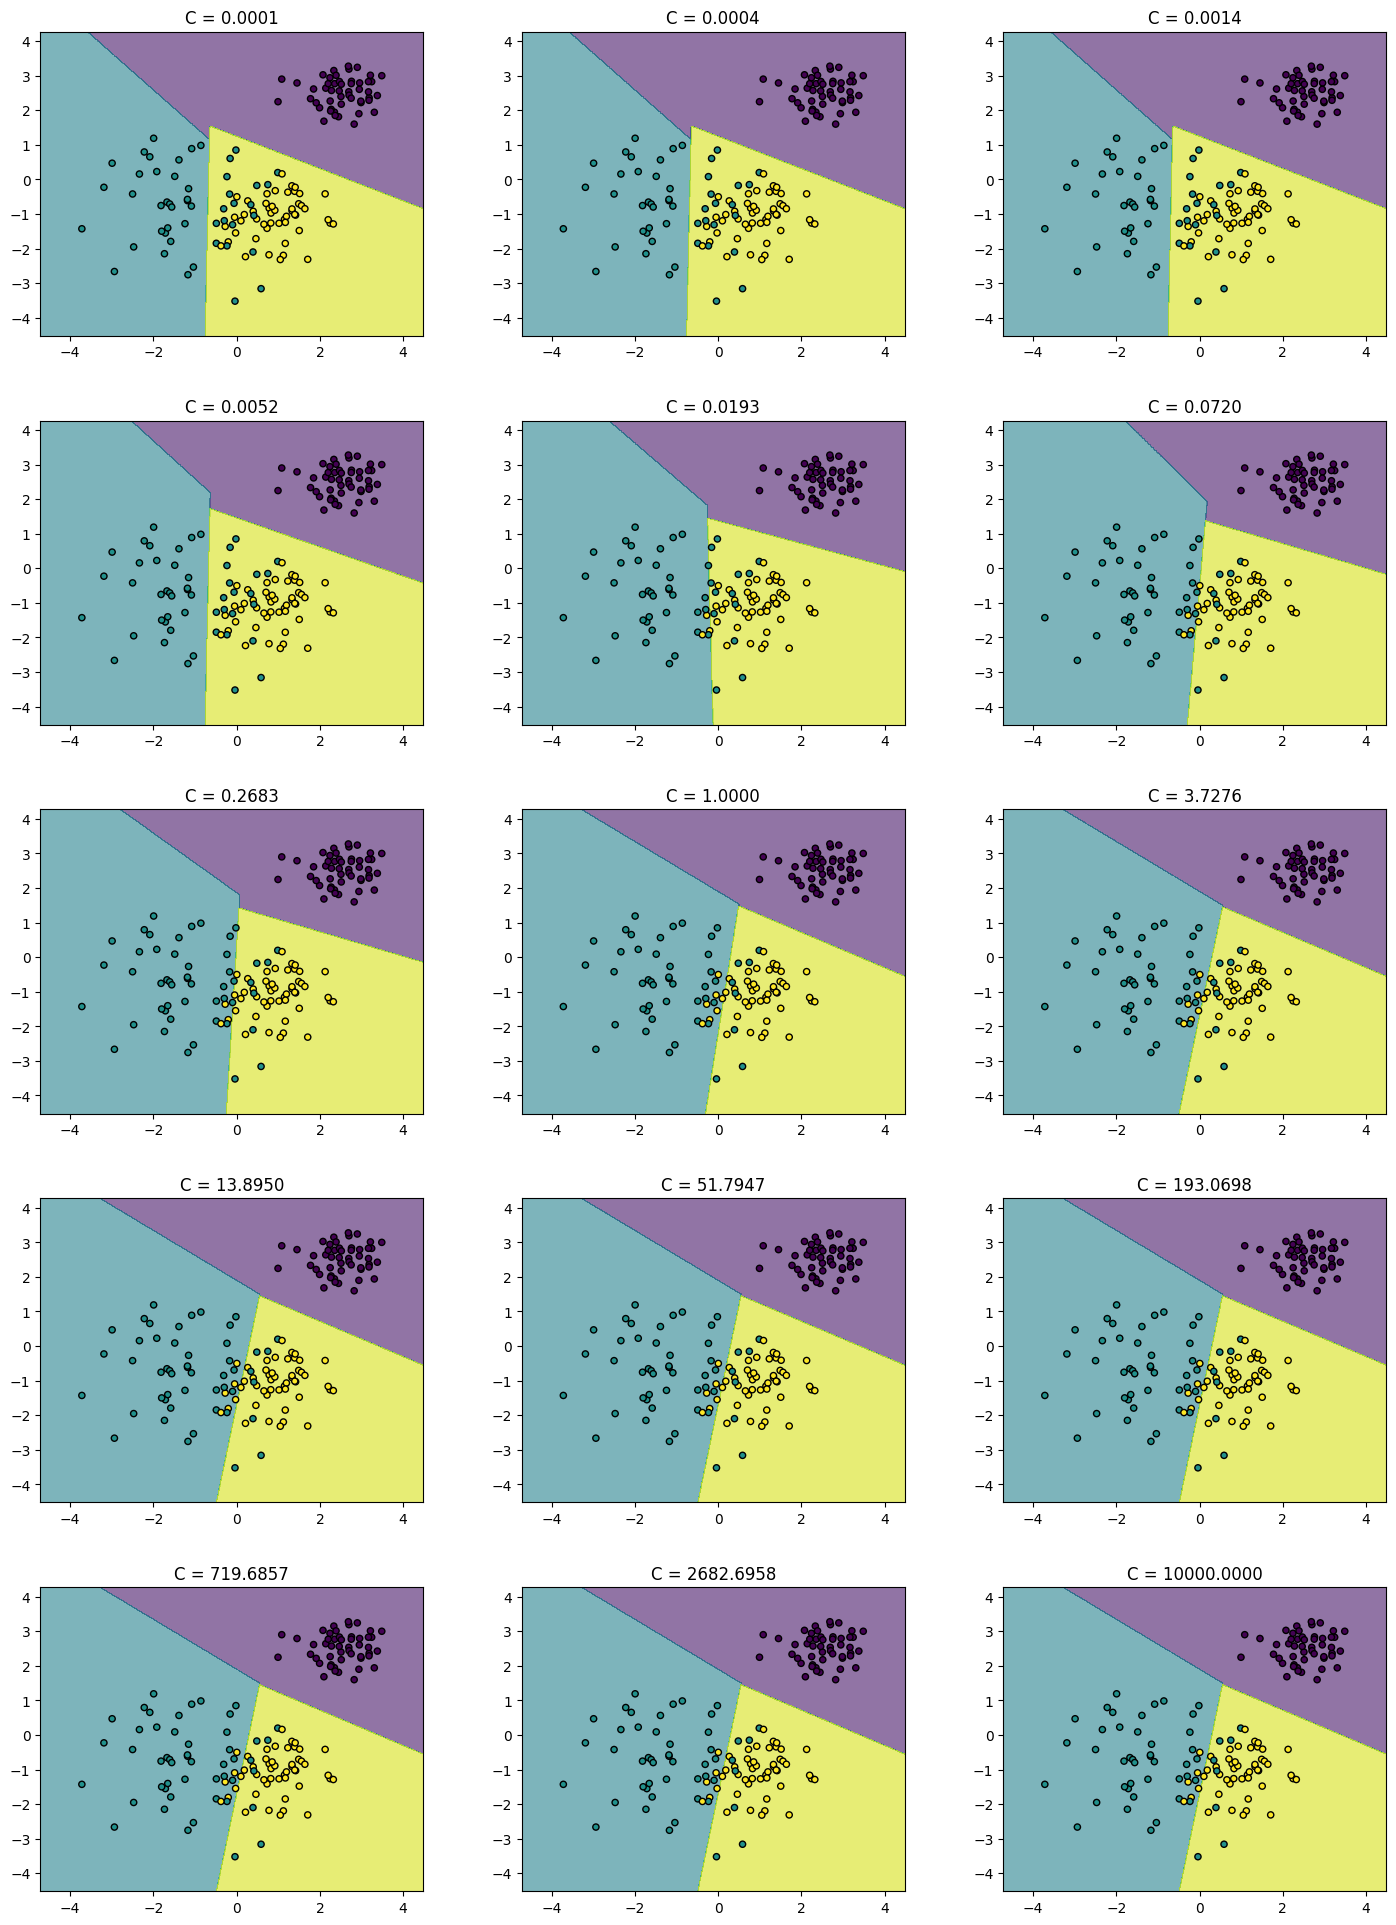

In [19]:
C_values = np.logspace(-4, 4, 15)  # C between 10^-4 e 10^4
Accuracy = [] 

fig, axes = plt.subplots(5, 3, figsize=(15, 20))
fig.tight_layout(pad=4.0) 

for i, (C, ax) in enumerate(zip(C_values, axes.flat)):
    clf = SVC(kernel='linear', C=C)
    clf.fit(x_train, y_train)

    y_pred = clf.predict(x_valid)
    acc = accuracy_score(y_valid, y_pred)  # Classification Error
    Accuracy.append(acc)

    # fig , ax = plt.subplots (1, 1, figsize =(12, 6))
    disp = DecisionBoundaryDisplay.from_estimator(
        clf , X, ax=ax , grid_resolution =1000 , alpha =0.6
        )
    ax.scatter(X[:, 0], X[:, 1], c=y, s=20, edgecolors='k')
    ax.set_title(f"C = {C:.4f}")
plt.show()

7. Donnez votre analyse des résultats obtenus.

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    As the value of C increases, the decision boundaries between Cyan and Yellow, as well as Cyan and Purple, move away from the center of the Cyan group, allowing more points from this class to be better classified. This aligns with the tendency of high C values to prioritize the error minimization term in the equation.
  </p>
  <p>
    On the other hand, the boundary between the Yellow and Purple groups tends to shift toward the Purple group, but with less intensity compared to the movement observed in the Cyan class boundaries. Since Cyan and Yellow are the groups with the highest variance, this could indicate that increasing C causes the boundaries to shift according to the variance of the respective classes.
  </p>
</div>

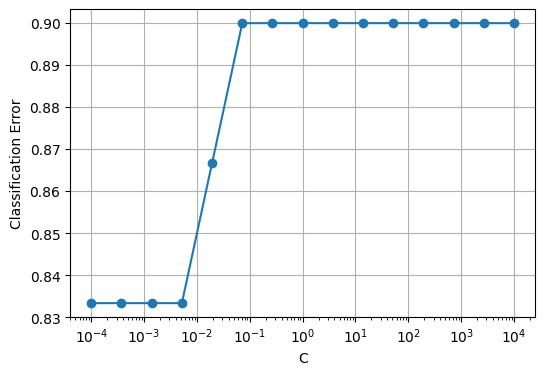

Best C value: 0.07196856730011514
Max Accuaracy Valid: 90.00%


In [21]:
plt.figure(figsize=(6, 4))
plt.semilogx(C_values, Accuracy, marker='o')
plt.xlabel('C')
plt.ylabel('Classification Error')
plt.grid(True)
plt.show()

best_C = C_values[np.argmax(Accuracy)]
print("Best C value:", best_C)
print(f"Max Accuaracy Valid: {np.max(Accuracy)*100:.2f}%")

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    We can also see that in some cases, even with an increase in C, the boundary shift occurs in a region of very low density or is minimal, which is reflected in the regions of constant accuracy in the graph above.
  </p>
</div>

8. Comparez les performances en généralisation d’un SVM linéaire et d’un modèle de regréssion softmax sur ces données.

In [16]:
clf = SVC(kernel='linear', C=best_C)
clf.fit(x_train, y_train)

y_pred = clf.predict(x_test)
acc_SVC = accuracy_score(y_test, y_pred)

In [18]:
model = LogisticRegression()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)
acc_LR = accuracy_score(y_test, y_pred)

print(f"Accuracy LR = {acc_LR *100:.2f}%")
print(f"Accuracy SVC = {acc_SVC *100:.2f}%")

Accuracy LR = 90.00%
Accuracy SVC = 93.33%


<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    This time, the results were slightly more divergent, with the SVC having a 3.33% advantage, clearly proving to be superior in this scenario.
  </p>
</div>